# TASK 4: Email Spam Detection with Machine Learning

## Objective: 
Build a Natural Language Processing (NLP) binary classifier that distinguishes spam emails from legitimate (ham) emails.

## Step 1: Import Required Libraries + Load Dataset

### 1.1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import nltk

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

#Download required NLTK resources:
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### 1.2. Dataset Loading

In [ ]:
df = pd.read_csv(
    "/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv",
    encoding="latin-1"
)

## Step 2: Data Loading and Class Distribution Check

### 2.1. Inspecting the dataset

In [ ]:
#Inspect Dataset
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
#Check dimensions:
df.shape

(5572, 5)

In [ ]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [ ]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [ ]:
#keep only useful columns
df = df[["v1", "v2"]]

In [ ]:
#Rename columns
df.columns = [
    "label",
    "text"
]

#Verify the structure
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 2.2. Check class distribution (spam vs ham)

#### 2.2.1. Calculate class counts

In [ ]:
# Count the number of messages in each class
class_counts = df["label"].value_counts()

class_counts

label
ham     4825
spam     747
Name: count, dtype: int64

#### 2.2.2. Calculate class percentages

In [ ]:
class_percentage = (
    df["label"]
    .value_counts(normalize=True)
    * 100
)

class_percentage

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

### 2.3. Visualize class distribution

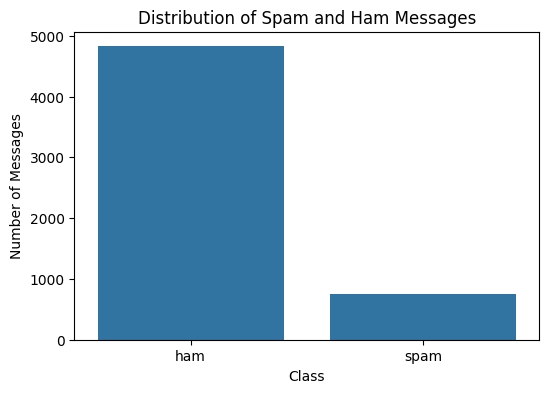

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Distribution of Spam and Ham Messages")

plt.xlabel("Class")

plt.ylabel("Number of Messages")

plt.show()

### Observation

The dataset is imbalanced, with ham messages representing 86.6% of the data and spam messages representing 13.4%. Therefore, evaluation metrics beyond accuracy are required to properly assess spam detection performance.

## Step 3: Text Preprocessing Pipeline

Raw text cannot be directly used by machine learning models. We need to transform messages into a clean and standardized format.

### 3.1. Import required NLP tools

In [ ]:
#Load English stopwords:
nltk.download("stopwords")

#Initialize tools
stop_words = set(stopwords.words("english"))

stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 3.2. Create preprocessing function

In [ ]:
def preprocess_text(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation and special characters
    text = re.sub(
        r"[^a-zA-Z]",
        " ",
        text
    )
    
    # Split text into words
    words = text.split()
    
    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    # Apply stemming
    words = [
        stemmer.stem(word)
        for word in words
    ]
    
    # Rejoin words into a sentence
    return " ".join(words)

### 3.3. Apply preprocessing to the dataset

In [ ]:
df["clean_text"] = df["text"].apply(
    preprocess_text
)

### 3.4. Compare original and processed text

In [ ]:
df[["text", "clean_text"]].head()

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


### Observation

Text preprocessing standardizes the email messages by reducing noise and normalizing word representations, improving the quality of features extracted for machine learning classification.

## Step 4: Feature Extraction Using TF-IDF Vectorizer

## TF-IDF Feature Extraction

TF-IDF (Term Frequency–Inverse Document Frequency) is a technique that converts text messages into numerical feature vectors that can be used by machine learning models.

It measures the importance of a word within a document relative to the entire dataset:

- **Term Frequency (TF):** measures how frequently a word appears in a specific message.
- **Inverse Document Frequency (IDF):** reduces the weight of words that appear frequently across all messages and increases the importance of rare, informative words.

The TF-IDF score is calculated as:

TF-IDF = TF × IDF

A higher TF-IDF value indicates that a word is more relevant for distinguishing a message from others.

### Implementation
### 4.1. Separate features and target

In [ ]:
#Input (X): processed text
X = df["clean_text"]

#Output (y): spam/ham label
y = df["label"]

### 4.2. Convert labels into numerical values

In [ ]:
#Convert: ham => 0 & spam => 1
y = y.map(
    {
        "ham": 0,
        "spam": 1
    }
)

#Verify
y.value_counts()

label
0    4825
1     747
Name: count, dtype: int64

### 4.3. Apply TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000
)

### 4.4. Check the generated features

In [ ]:
# Transform the text:
X_tfidf = tfidf.fit_transform(X)

In [ ]:
#View extracted words
tfidf.get_feature_names_out()[:20]

array(['aah', 'aathi', 'abi', 'abil', 'abiola', 'abj', 'abl', 'abnorm',
       'absolutli', 'abt', 'abta', 'aburo', 'abus', 'ac', 'academ', 'acc',
       'accent', 'accentur', 'accept', 'access'], dtype=object)

## Step 5: Train/Test Split

### 5.1. Split the dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42, #Ensures reproducibility, every time we run the notebook, we obtain the same split.
    stratify=y
)

### 5.2. Verify the split

In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data: (4457, 5000)
Testing data: (1115, 5000)
Training labels: (4457,)
Testing labels: (1115,)


## Step 6: Train Multiple Classifiers

We will train two different classification models:

+ **Multinomial Naive Bayes:** the standard baseline model for text classification using word frequencies/TF-IDF.
+ **Logistic Regression:** an alternative linear classifier that often performs very well on TF-IDF text features.


### 6.1. Multinomial Naive Bayes

Multinomial Naive Bayes is widely used in NLP because it:

+ works efficiently with high-dimensional text data
+ handles sparse TF-IDF matrices well
+ performs well for spam filtering and document classification

In [ ]:
#Train the model
nb_model = MultinomialNB()

nb_model.fit(
    X_train,
    y_train
)

MultinomialNB()

In [ ]:
#Generate Predictions
y_pred_nb = nb_model.predict(
    X_test
)

### 6.2. Logistic Regression

Logistic Regression is a strong baseline for binary classification because it:

+ learns the relationship between TF-IDF features and class labels
+ provides probabilistic predictions
+ performs well with sparse text representations

In [ ]:
#Train the model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
#Generate predictions
y_pred_lr = lr_model.predict(
    X_test
)

## Step 7: Model Evaluation

### 7.1. Evaluation Function

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(y_test, y_pred, model_name):
    
    print("Model:", model_name)
    print("-" * 40)
    
    print("Accuracy:",
          accuracy_score(y_test, y_pred))
    
    print("Precision:",
          precision_score(y_test, y_pred))
    
    print("Recall:",
          recall_score(y_test, y_pred))
    
    print("F1-score:",
          f1_score(y_test, y_pred))
    
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Ham", "Spam"]
        )
    )

### 7.2. Evaluate Multinomial Naive Bayes

In [ ]:
evaluate_model(
    y_test,
    y_pred_nb,
    "Multinomial Naive Bayes"
)

Model: Multinomial Naive Bayes
----------------------------------------
Accuracy: 0.9695067264573991
Precision: 0.9914529914529915
Recall: 0.7785234899328859
F1-score: 0.8721804511278195

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.99      0.78      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



### 7.3. Evaluate Logistic Regression

In [ ]:
evaluate_model(
    y_test,
    y_pred_lr,
    "Logistic Regression"
)

Model: Logistic Regression
----------------------------------------
Accuracy: 0.9650224215246637
Precision: 0.9910714285714286
Recall: 0.7449664429530202
F1-score: 0.8505747126436781

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



### 7.4. Confusion Matrix Visualization

#### 7.4.1. Naive Bayes

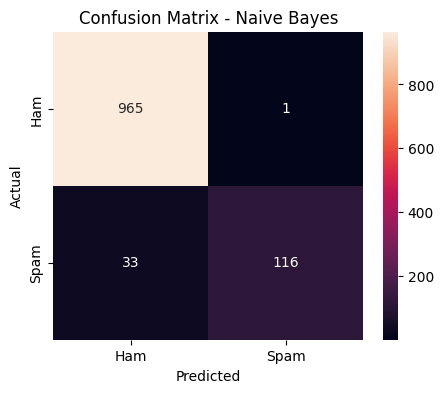

In [ ]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")

plt.show()

#### 7.4.2. Logistic Regression

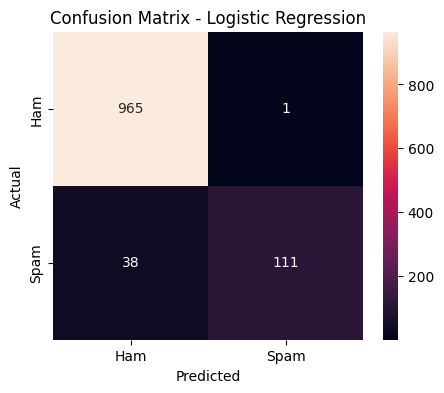

In [ ]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### 7.5. Compare Models in a Table

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_lr)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_lr)
    ],
    
    "F1-score": [
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_lr)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Multinomial Naive Bayes,0.969507,0.991453,0.778523,0.872180
1,Logistic Regression,0.965022,0.991071,0.744966,0.850575


## Observation

Multinomial Naive Bayes achieved the best overall performance with the highest recall (77.85%) and F1-score (87.22%). Therefore, it is selected as the preferred model for spam detection.

## Step 8: Why is Recall Important in Spam Detection?

Recall measures the proportion of actual spam messages that are correctly identified by the model. In spam detection, a low recall means that some spam messages are incorrectly classified as legitimate and reach the user's inbox.

Therefore, maximizing recall is important to reduce false negatives and improve the system's ability to detect unwanted messages. However, recall should be balanced with precision to avoid incorrectly blocking legitimate emails.

## Step 9: WordCloud Visualizations for Spam and Ham Messages
A WordCloud provides a visual representation of the most frequent words in each class:

+ Spam WordCloud: highlights common words found in spam messages.
+ Ham WordCloud: highlights common words found in legitimate messages.

### 9.1. Install and import WordCloud

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

### 9.2. Separate spam and ham messages

In [ ]:
#We combine all cleaned spam messages into one text corpus.
spam_text = " ".join(
    df[df["label"] == "spam"]["clean_text"]
)

#We combine all cleaned ham messages into another corpus
ham_text = " ".join(
    df[df["label"] == "ham"]["clean_text"]
)

### 9.3. Generate Spam WordCloud

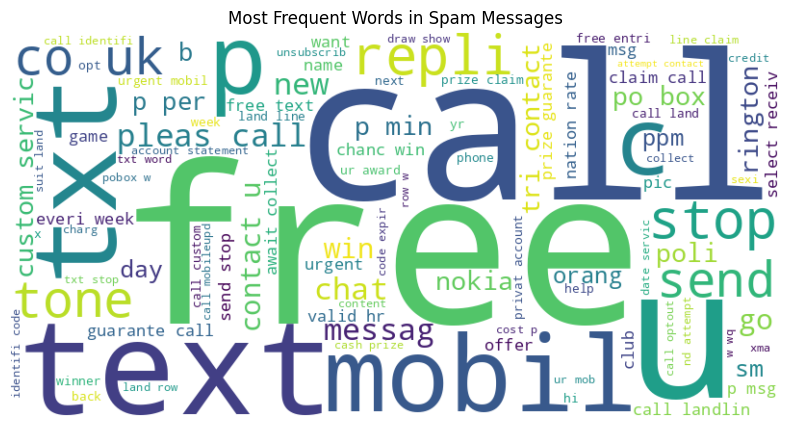

In [ ]:
spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(spam_text)


plt.figure(figsize=(10,5))

plt.imshow(
    spam_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Most Frequent Words in Spam Messages"
)

plt.show()

### 9.4. Generate Ham WordCloud

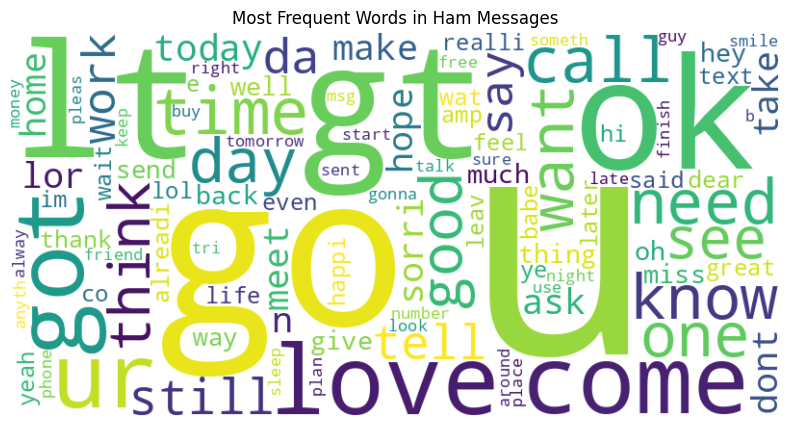

In [ ]:
ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(ham_text)


plt.figure(figsize=(10,5))

plt.imshow(
    ham_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Most Frequent Words in Ham Messages"
)

plt.show()

## Self-Sourcing References

This project was completed using publicly available resources:

- **Dataset:** Search **"SMS Spam Collection Dataset"** on Kaggle or the UCI Machine Learning Repository to obtain the dataset.
- **Documentation:** Refer to the NLTK documentation for text preprocessing and the Scikit-learn documentation for text vectorization, classification models, and evaluation metrics.
- **Learning Resources:** Search **"email spam detection Python NLP tutorial scikit-learn"** on YouTube for implementation guidance.